# MC Dropout for Uncertainty Quantification in CLIPSeg



## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from transformers import AutoProcessor, CLIPSegForImageSegmentation
from transformers.image_utils import load_image
import tifffile as tiff
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

## 2. Define CLIPSeg with Dropout in Encoder

In [2]:
class CLIPSegWithEncoderDropout(nn.Module):
    """
    Wrapper around CLIPSeg that adds dropout to the vision encoder.

    We modify the CLIP vision model itself to have dropout,
    then use the standard CLIPSeg forward pass.
    """
    def __init__(self, base_model, dropout_rate=0.2):
        super().__init__()
        self.model = base_model
        self.dropout_rate = dropout_rate

        # Add dropout layers to the vision encoder's MLP layers
        # These are the feedforward layers after each attention block
        self._add_dropout_to_encoder()

    def _add_dropout_to_encoder(self):
        """
        Add dropout to the vision encoder's MLP layers.
        Each transformer block has: Attention -> LayerNorm -> MLP -> LayerNorm
        We add dropout after the MLP.
        """
        # Access the vision transformer encoder layers
        encoder_layers = self.model.clip.vision_model.encoder.layers

        for layer in encoder_layers:
            # Each layer has an MLP
            # Add a dropout layer after the MLP's first activation
            original_mlp_forward = layer.mlp.forward
            dropout = nn.Dropout(p=self.dropout_rate)

            # Create a new forward function that includes dropout
            def make_mlp_forward_with_dropout(orig_forward, dropout_layer):
                def forward_with_dropout(hidden_states):
                    # Run original MLP
                    output = orig_forward(hidden_states)
                    # Apply dropout if in training mode
                    if dropout_layer.training:
                        output = dropout_layer(output)
                    return output
                return forward_with_dropout

            # Replace the MLP forward with our dropout version
            layer.mlp.forward = make_mlp_forward_with_dropout(original_mlp_forward, dropout)

            # Store dropout layer so we can enable/disable it
            if not hasattr(layer.mlp, 'dropout_layers'):
                layer.mlp.dropout_layers = []
            layer.mlp.dropout_layers.append(dropout)

    def enable_dropout(self):
        """
        Enable dropout in the encoder for MC sampling.
        """
        # Enable all dropout layers we added to the vision encoder
        for layer in self.model.clip.vision_model.encoder.layers:
            if hasattr(layer.mlp, 'dropout_layers'):
                for dropout in layer.mlp.dropout_layers:
                    dropout.train()

        # Also enable any existing dropout in the model
        for module in self.model.clip.vision_model.modules():
            if isinstance(module, nn.Dropout):
                module.train()

    def disable_dropout(self):
        """
        Disable dropout for deterministic inference.
        """
        for layer in self.model.clip.vision_model.encoder.layers:
            if hasattr(layer.mlp, 'dropout_layers'):
                for dropout in layer.mlp.dropout_layers:
                    dropout.eval()

        for module in self.model.clip.vision_model.modules():
            if isinstance(module, nn.Dropout):
                module.eval()

    def forward(self, **kwargs):
        """
        Standard forward pass - dropout is built into the encoder now.
        """
        return self.model(**kwargs)


## 3. Load Model and Processor

In [3]:
# Load base CLIPSeg model
processor = AutoProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
base_model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

# Wrap with encoder dropout
dropout_rate = 0.1
model = CLIPSegWithEncoderDropout(base_model, dropout_rate=dropout_rate)

model.eval()

print(f"Model loaded with encoder dropout rate: {dropout_rate}")
print(f"Dropout location: CLIP Vision Encoder (during feature extraction)")
print(f"Dropout injected into {len(model.model.clip.vision_model.encoder.layers)} transformer layers")
print(f"Each layer's MLP now includes dropout for MC sampling")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded with encoder dropout rate: 0.1
Dropout location: CLIP Vision Encoder (during feature extraction)
Dropout injected into 12 transformer layers
Each layer's MLP now includes dropout for MC sampling


## 4. Load Image and Ground Truth

In [4]:
# Load image
url = "/content/021.jpg"
image = load_image(url)

# Define classes
# texts = ['unlabeled', 'paved-area', 'dirt', 'grass', 'gravel', 'water', 'rocks', 'pool', 'vegetation', 'roof', 'wall', 'window', 'door', 'fence', 'fence-pole', 'person', 'dog', 'car', 'bicycle', 'tree', 'bald-tree', 'ar-marker', 'obstacle', 'conflicting']
# indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
texts = ['paved-area', 'dirt', 'grass', 'rocks', 'vegetation', 'person', 'dog', 'bicycle', 'tree']
indices = [1, 2, 3, 6, 8, 15, 16, 18, 19]

print(f"Image size: {np.array(image).shape}")
print(f"Classes: {texts}")

Image size: (4000, 6000, 3)
Classes: ['paved-area', 'dirt', 'grass', 'rocks', 'vegetation', 'person', 'dog', 'bicycle', 'tree']


In [5]:
# Load ground truth mask
tiff_path = "/content/021.tiff"
mask = tiff.imread(tiff_path)

print(f"Mask shape: {mask.shape}")
print(f"Mask dtype: {mask.dtype}")

Mask shape: (800, 1200, 24)
Mask dtype: int64


In [6]:
# Prepare ground truth (resize to match CLIPSeg output)
H, W = 352, 352  # CLIPSeg output size
ground_truth = np.zeros((H, W), dtype=np.int64)

for i, idx in enumerate(indices):
    channel = mask[:, :, idx]
    channel_resized = np.array(
        Image.fromarray(channel.astype(np.uint8)).resize((W, H), Image.NEAREST)
    )
    ground_truth[channel_resized == 255] = i

print(f"Ground truth shape: {ground_truth.shape}")
print(f"Ground truth classes: {np.unique(ground_truth)}")
print(f"Class distribution:")
for i, text in enumerate(texts):
    count = (ground_truth == i).sum()
    print(f"  {text}: {count} pixels ({100*count/(H*W):.2f}%)")

Ground truth shape: (352, 352)
Ground truth classes: [0 1 2 4 5 7]
Class distribution:
  paved-area: 38538 pixels (31.10%)
  dirt: 4665 pixels (3.77%)
  grass: 74734 pixels (60.32%)
  rocks: 0 pixels (0.00%)
  vegetation: 2036 pixels (1.64%)
  person: 436 pixels (0.35%)
  dog: 0 pixels (0.00%)
  bicycle: 3495 pixels (2.82%)
  tree: 0 pixels (0.00%)


## 5. MC Dropout Inference Function

run N forward passes with dropout enabled in the encoder.

In [7]:
def mc_dropout_predict(model, processor, image, texts, n_samples=30, device='cpu'):
    """
    Perform MC Dropout inference with encoder dropout.

    Args:
        model: CLIPSegWithEncoderDropout model
        processor: CLIPSeg processor
        image: PIL Image
        texts: List of class names
        n_samples: Number of forward passes (default: 30)
        device: 'cpu' or 'cuda'

    Returns:
        mean_probs: (H, W, num_classes) - Mean probabilities across samples
        std_probs: (H, W, num_classes) - Standard deviation (uncertainty)
        all_probs: (n_samples, num_classes, H, W) - All predictions
    """
    model.to(device)

    # Prepare inputs
    inputs = processor(
        text=texts,
        images=[image] * len(texts),
        padding=True,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Enable dropout in the encoder for MC sampling
    model.enable_dropout()

    # Collect predictions from multiple forward passes
    all_probs = []

    print(f"Running {n_samples} forward passes with encoder dropout...")
    with torch.no_grad():
        for i in tqdm(range(n_samples)):
            outputs = model(**inputs)
            logits = outputs.logits  # Shape: (num_classes, H, W)

            # Apply sigmoid (CLIPSeg uses binary classification per class)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())

            del outputs, logits, probs
            torch.cuda.empty_cache()

    # Stack: (n_samples, num_classes, H, W)
    all_probs = np.stack(all_probs, axis=0)

    # Compute statistics across samples
    mean_probs = all_probs.mean(axis=0)  # (num_classes, H, W)
    std_probs = all_probs.std(axis=0)    # (num_classes, H, W)

    # Transpose to (H, W, num_classes) for easier handling
    mean_probs = mean_probs.transpose(1, 2, 0)
    std_probs = std_probs.transpose(1, 2, 0)

    return mean_probs, std_probs, all_probs

## 6. Run MC Dropout Inference

In [15]:
# Set parameters
n_samples = 30
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device: {device}")
print(f"Number of MC samples: {n_samples}")
print(f"Dropout rate: {dropout_rate}")
print(f"Dropout location: Vision Encoder (during feature extraction)")

# Run MC Dropout
start_time = time.time()
mean_probs, std_probs, all_probs = mc_dropout_predict(
    model, processor, image, texts, n_samples=n_samples, device=device
)
inference_time = time.time() - start_time

print(f"\nInference completed in {inference_time:.2f} seconds")
print(f"Mean probabilities shape: {mean_probs.shape}")
print(f"Uncertainty (std) shape: {std_probs.shape}")

Device: cuda
Number of MC samples: 30
Dropout rate: 0.1
Dropout location: Vision Encoder (during feature extraction)
Running 30 forward passes with encoder dropout...


100%|██████████| 30/30 [00:09<00:00,  3.14it/s]


Inference completed in 13.82 seconds
Mean probabilities shape: (352, 352, 9)
Uncertainty (std) shape: (352, 352, 9)


## 7. Generate Predictions and Compute Accuracy

In [16]:
# Get point predictions (argmax over classes)
predictions = mean_probs.argmax(axis=-1)

# Predictive entropy
entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-8), axis=-1)
num_classes = mean_probs.shape[-1]
max_entropy = np.log(num_classes)
normalized_entropy = entropy / max_entropy

print(f"Predictions shape: {predictions.shape}")
print(f"Predicted classes: {np.unique(predictions)}")

# Compute overall accuracy
accuracy = (predictions == ground_truth).mean()
print(f"\n{'='*50}")
print(f"OVERALL ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'='*50}")

Predictions shape: (352, 352)
Predicted classes: [0 1 2 3 4 5 7]

OVERALL ACCURACY: 0.8389 (83.89%)


In [17]:
# Per-class accuracy
print(f"\n{'='*50}")
print(f"PER-CLASS ACCURACY")
print(f"{'='*50}")

for i, text in enumerate(texts):
    class_mask = ground_truth == i
    if class_mask.sum() > 0:
        class_acc = (predictions[class_mask] == ground_truth[class_mask]).mean()
        print(f"{text:15s}: {class_acc:.4f} ({class_acc*100:.2f}%) - {class_mask.sum()} pixels")
    else:
        print(f"{text:15s}: No pixels in ground truth")


PER-CLASS ACCURACY
paved-area     : 0.6804 (68.04%) - 38538 pixels
dirt           : 0.9831 (98.31%) - 4665 pixels
grass          : 0.9599 (95.99%) - 74734 pixels
rocks          : No pixels in ground truth
vegetation     : 0.0093 (0.93%) - 2036 pixels
person         : 0.4885 (48.85%) - 436 pixels
dog            : No pixels in ground truth
bicycle        : 0.3342 (33.42%) - 3495 pixels
tree           : No pixels in ground truth


## 8. Analyze Uncertainty (Epistemic Uncertainty)

The standard deviation across MC samples represents model uncertainty.

With encoder dropout, this uncertainty reflects variations in how the model perceives and understands the image.

In [18]:
# Uncertainty statistics
mean_uncertainty_per_pixel = normalized_entropy.mean()

print(f"\n{'='*50}")
print(f"UNCERTAINTY STATISTICS (Encoder Dropout)")
print(f"{'='*50}")
print(f"Mean uncertainty (avg across all pixels): {mean_uncertainty_per_pixel:.6f}")
print(f"")


UNCERTAINTY STATISTICS (Encoder Dropout)
Mean uncertainty (avg across all pixels): 0.615952



In [19]:
# Per-class uncertainty using normalized entropy
print(f"\n{'='*50}")
print("PER-CLASS UNCERTAINTY (Mean ± Std)")
print(f"{'='*50}")

for i, text in enumerate(texts):
    class_mask = ground_truth == i

    if class_mask.sum() > 0:
        class_entropy = normalized_entropy[class_mask]

        print(f"{text:15s}: "
              f"{class_entropy.mean():.6f} ± "
              f"{class_entropy.std():.6f}")
    else:
        print(f"{text:15s}: No pixels in ground truth")


PER-CLASS UNCERTAINTY (Mean ± Std)
paved-area     : 0.492606 ± 0.191380
dirt           : 0.684380 ± 0.070216
grass          : 0.665881 ± 0.069913
rocks          : No pixels in ground truth
vegetation     : 0.674221 ± 0.107639
person         : 0.864822 ± 0.084252
dog            : No pixels in ground truth
bicycle        : 0.752080 ± 0.116984
tree           : No pixels in ground truth


In [20]:
# Uncertainty vs Errors
errors = (predictions != ground_truth)
correct = (predictions == ground_truth)

uncertainty_when_wrong = normalized_entropy[errors]
uncertainty_when_correct = normalized_entropy[correct]

print(f"\n{'='*50}")
print(f"UNCERTAINTY VS PREDICTION CORRECTNESS")
print(f"{'='*50}")
print(f"Mean uncertainty when CORRECT: {uncertainty_when_correct.mean():.6f}")
print(f"Mean uncertainty when WRONG:   {uncertainty_when_wrong.mean():.6f}")
print(f"Difference: {uncertainty_when_wrong.mean() - uncertainty_when_correct.mean():.6f}")
print(f"")
print(f"Ideally, uncertainty should be HIGHER when predictions are wrong.")
if uncertainty_when_wrong.mean() > uncertainty_when_correct.mean():
    print(f"Good. Encoder dropout produces higher uncertainty for errors.")
else:
    print(f"Warning: Uncertainty is not reliably indicating errors.")


UNCERTAINTY VS PREDICTION CORRECTNESS
Mean uncertainty when CORRECT: 0.628743
Mean uncertainty when WRONG:   0.549346
Difference: -0.079397

Ideally, uncertainty should be HIGHER when predictions are wrong.


## 9. Visualizations

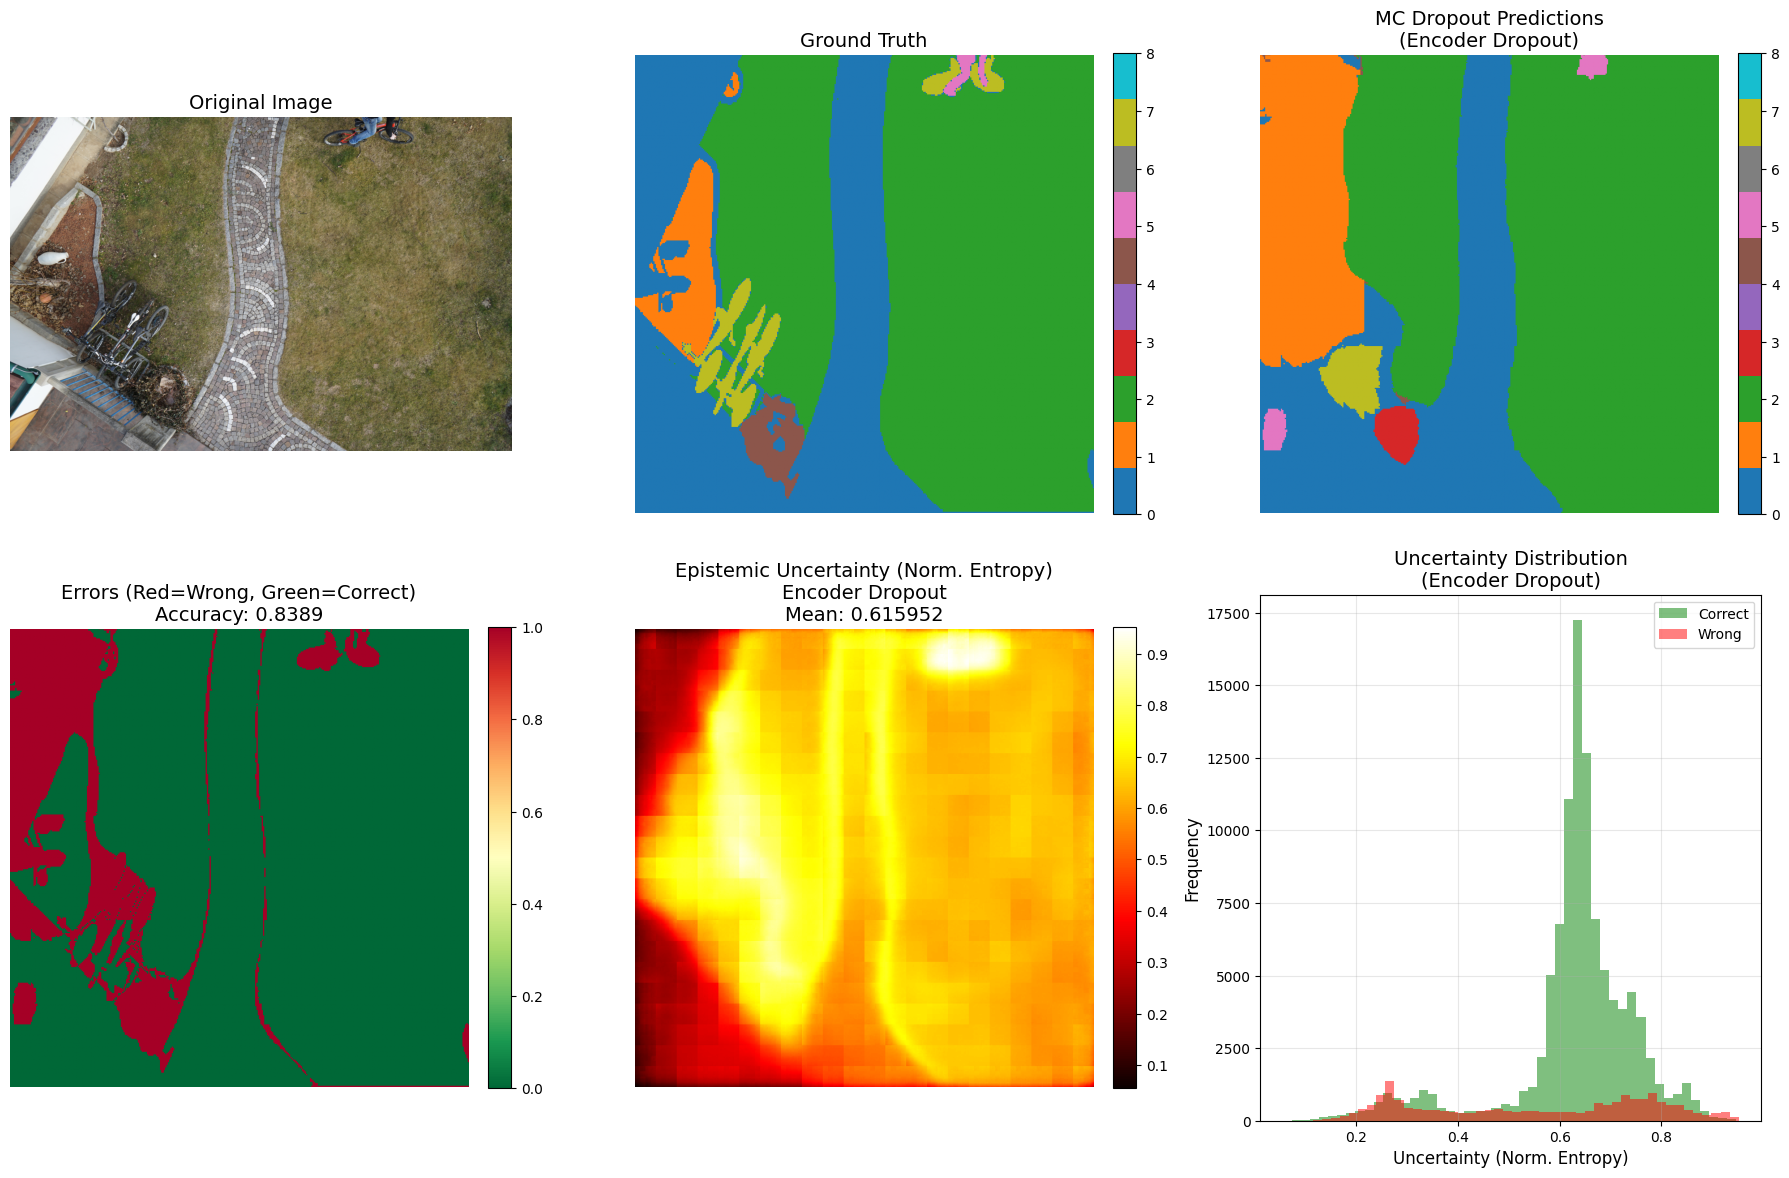


Visualization saved as 'mc_dropout_encoder_results.png'


In [21]:
# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original Image', fontsize=14)
axes[0, 0].axis('off')

# Ground truth
im1 = axes[0, 1].imshow(ground_truth, cmap='tab10', vmin=0, vmax=len(texts)-1)
axes[0, 1].set_title('Ground Truth', fontsize=14)
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Predictions
im2 = axes[0, 2].imshow(predictions, cmap='tab10', vmin=0, vmax=len(texts)-1)
axes[0, 2].set_title('MC Dropout Predictions\n(Encoder Dropout)', fontsize=14)
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Error map
error_map = (predictions != ground_truth).astype(float)
im3 = axes[1, 0].imshow(error_map, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1, 0].set_title(f'Errors (Red=Wrong, Green=Correct)\nAccuracy: {accuracy:.4f}', fontsize=14)
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Uncertainty map (normalized entropy per pixel)
im4 = axes[1, 1].imshow(normalized_entropy, cmap='hot')
axes[1, 1].set_title(f'Epistemic Uncertainty (Norm. Entropy)\nEncoder Dropout\nMean: {normalized_entropy.mean():.6f}', fontsize=14)
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Uncertainty histogram
axes[1, 2].hist(uncertainty_when_correct, bins=50, alpha=0.5, label='Correct', color='green')
axes[1, 2].hist(uncertainty_when_wrong, bins=50, alpha=0.5, label='Wrong', color='red')
axes[1, 2].set_xlabel('Uncertainty (Norm. Entropy)', fontsize=12)
axes[1, 2].set_ylabel('Frequency', fontsize=12)
axes[1, 2].set_title('Uncertainty Distribution\n(Encoder Dropout)', fontsize=14)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mc_dropout_encoder_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'mc_dropout_encoder_results.png'")


## 10. Example Predictions with Uncertainty



In [82]:
print(f"\n{'='*70}")
print(f"EXAMPLE PREDICTIONS WITH UNCERTAINTY")
print(f"{'='*70}")

# Sample random pixels
np.random.seed(42)
n_examples = 5
sample_rows = np.random.randint(0, H, size=n_examples)
sample_cols = np.random.randint(0, W, size=n_examples)

for i, (row, col) in enumerate(zip(sample_rows, sample_cols)):
    true_class = ground_truth[row, col]
    pred_class = predictions[row, col]
    is_correct = true_class == pred_class

    # Get probabilities and uncertainties for this pixel
    pixel_probs = mean_probs[row, col]
    pixel_std = std_probs[row, col]
    pixel_normalized_entropy = normalized_entropy[row, col] # Get normalized entropy for the pixel

    print(f"\nPixel ({row}, {col}):")
    print(f"  True class:      {texts[true_class]}")
    print(f"  Predicted class: {texts[pred_class]}")
    print(f"  Correct: {'✓' if is_correct else '✗'}")
    print(f"  Uncertainty: {pixel_normalized_entropy:.6f}") # Display normalized entropy
    print(f"  ")
    print(f"  Top-3 predictions (prob \u00b1 std):")

    # Show top 3 classes by probability
    top3_indices = np.argsort(pixel_probs)[::-1][:3]
    for idx in top3_indices:
        prob = pixel_probs[idx]
        std = pixel_std[idx]
        marker = "->" if idx == pred_class else "  "
        print(f"    {marker} {texts[idx]:15s}: {prob:.4f} \u00b1 {std:.6f}")



EXAMPLE PREDICTIONS WITH UNCERTAINTY

Pixel (102, 188):
  True class:      paved-area
  Predicted class: grass
  Correct: ✗
  Uncertainty: 0.774979
  
  Top-3 predictions (prob ± std):
    -> grass          : 0.5008 ± 0.059368
       paved-area     : 0.4910 ± 0.074427
       vegetation     : 0.2535 ± 0.095815

Pixel (348, 20):
  True class:      paved-area
  Predicted class: paved-area
  Correct: ✓
  Uncertainty: 0.181947
  
  Top-3 predictions (prob ± std):
    -> paved-area     : 0.0698 ± 0.048098
       dirt           : 0.0230 ± 0.011160
       rocks          : 0.0151 ± 0.011965

Pixel (270, 102):
  True class:      vegetation
  Predicted class: paved-area
  Correct: ✗
  Uncertainty: 0.833173
  
  Top-3 predictions (prob ± std):
    -> paved-area     : 0.1845 ± 0.053059
       bicycle        : 0.1597 ± 0.158170
       rocks          : 0.1369 ± 0.061637

Pixel (106, 121):
  True class:      grass
  Predicted class: grass
  Correct: ✓
  Uncertainty: 0.676818
  
  Top-3 predictions (p

## 11. Save Results

In [ ]:
results_dict = {
    'method': 'MC Dropout (Encoder)',
    'dropout_location': 'CLIP Vision Encoder',
    'dropout_rate': dropout_rate,
    'n_samples': n_samples,
    'accuracy': float(accuracy),
    'inference_time': inference_time,
    'mean_uncertainty': float(mean_uncertainty_per_pixel.mean()),
    'uncertainty_correct': float(uncertainty_when_correct.mean()),
    'uncertainty_wrong': float(uncertainty_when_wrong.mean()),
    'predictions': predictions.tolist(),
    'uncertainty_map': max_uncertainty_per_pixel.tolist()
}

import json
with open('mc_dropout_encoder_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("Results saved to 'mc_dropout_encoder_results.json'")

## Analyze: How Many MC Samples Are Needed?

Test different numbers of MC samples (5, 10, 20, 30, 50, 100) to determine when uncertainty estimates stabilize.


In [10]:
# ==========================================
# Test Different Sample Sizes
# ==========================================

import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Test these sample sizes
sample_sizes = [5, 10, 20, 30, 50, 100]

# Store results
convergence_results = []

print("="*70)
print("Running MC Dropout with Different Sample Sizes")
print("="*70)

for n in sample_sizes:
    print(f"\n{'='*50}")
    print(f"Testing n_samples = {n}")
    print(f"{'='*50}")

    # Run MC Dropout with this sample size
    start_time = time.time()

    mean_probs_n, std_probs_n, all_probs_n = mc_dropout_predict(
    model, processor, image, texts, n_samples=n, device=device
    )

    elapsed_time = time.time() - start_time

    # Get predictions
    predictions_n = mean_probs_n.argmax(axis=-1)

    # Calculate metrics
    accuracy_n = (predictions_n == ground_truth).mean()

    # Uncertainty metrics
    max_uncertainty_n = std_probs_n.max(axis=-1)
    mean_uncertainty_n = max_uncertainty_n.mean()
    std_uncertainty_n = max_uncertainty_n.std()

    # Uncertainty calibration
    entropy_n = -np.sum(mean_probs_n * np.log(mean_probs_n + 1e-8), axis=-1)
    num_classes_n = mean_probs_n.shape[-1]
    max_entropy_n = np.log(num_classes_n)
    normalized_entropy_n = entropy_n / max_entropy_n

    errors_n = (predictions_n != ground_truth)
    correct_n = (predictions_n == ground_truth)

    uncertainty_when_wrong_n = normalized_entropy_n[errors_n].mean()
    uncertainty_when_correct_n = normalized_entropy_n[correct_n].mean()

    uncertainty_separation_n = uncertainty_when_wrong_n - uncertainty_when_correct_n

    # Store results
    result = {
        'n_samples': n,
        'accuracy': accuracy_n,
        'mean_uncertainty': mean_uncertainty_n,
        'std_uncertainty': std_uncertainty_n,
        'uncertainty_when_correct': uncertainty_when_correct_n,
        'uncertainty_when_wrong': uncertainty_when_wrong_n,
        'uncertainty_separation': uncertainty_separation_n,
        'time_seconds': elapsed_time
    }
    convergence_results.append(result)

    # Print summary
    print(f"\nResults for n={n}:")
    print(f"  Accuracy: {accuracy_n:.4f}")
    print(f"  Mean uncertainty: {mean_uncertainty_n:.6f}")
    print(f"  Uncertainty separation: {uncertainty_separation_n:.6f}")
    print(f"  Time: {elapsed_time:.2f}s")

# Convert to DataFrame for easy viewing
df_convergence = pd.DataFrame(convergence_results)

print("\n" + "="*70)
print("CONVERGENCE STUDY RESULTS")
print("="*70)
print(df_convergence.to_string(index=False))

TESTING CONVERGENCE: Running MC Dropout with Different Sample Sizes

Testing n_samples = 5
Running 5 forward passes with encoder dropout...


100%|██████████| 5/5 [00:04<00:00,  1.25it/s]



Results for n=5:
  Accuracy: 0.4946
  Mean uncertainty: 0.107581
  Uncertainty separation: 0.024179
  Time: 9.90s

Testing n_samples = 10
Running 10 forward passes with encoder dropout...


100%|██████████| 10/10 [00:08<00:00,  1.23it/s]



Results for n=10:
  Accuracy: 0.3724
  Mean uncertainty: 0.110440
  Uncertainty separation: 0.039102
  Time: 13.53s

Testing n_samples = 20
Running 20 forward passes with encoder dropout...


...


Results for n=30:
  Accuracy: 0.4465
  Mean uncertainty: 0.120847
  Uncertainty separation: 0.005111
  Time: 30.66s

Testing n_samples = 50
Running 50 forward passes with encoder dropout...


100%|██████████| 50/50 [00:41<00:00,  1.20it/s]



Results for n=50:
  Accuracy: 0.4757
  Mean uncertainty: 0.126735
  Uncertainty separation: -0.000040
  Time: 48.46s

Testing n_samples = 100
Running 100 forward passes with encoder dropout...


100%|██████████| 100/100 [01:22<00:00,  1.21it/s]



Results for n=100:
  Accuracy: 0.4458
  Mean uncertainty: 0.119878
  Uncertainty separation: 0.013054
  Time: 89.72s

CONVERGENCE STUDY RESULTS
 n_samples  accuracy  mean_uncertainty  std_uncertainty  uncertainty_when_correct  uncertainty_when_wrong  uncertainty_separation  time_seconds
         5  0.494617          0.107581         0.028693                  0.929170                0.953349                0.024179      9.903954
        10  0.372401          0.110440         0.023391                  0.896478                0.935579                0.039102     13.534126
        20  0.485416          0.126964         0.033217                  0.964866                0.968096                0.003229     22.483180
        30  0.446531          0.120847         0.030864                  0.948989                0.954100                0.005111     30.656060
        50  0.475747          0.126735         0.033549                  0.950876                0.950836               -0.000040     4

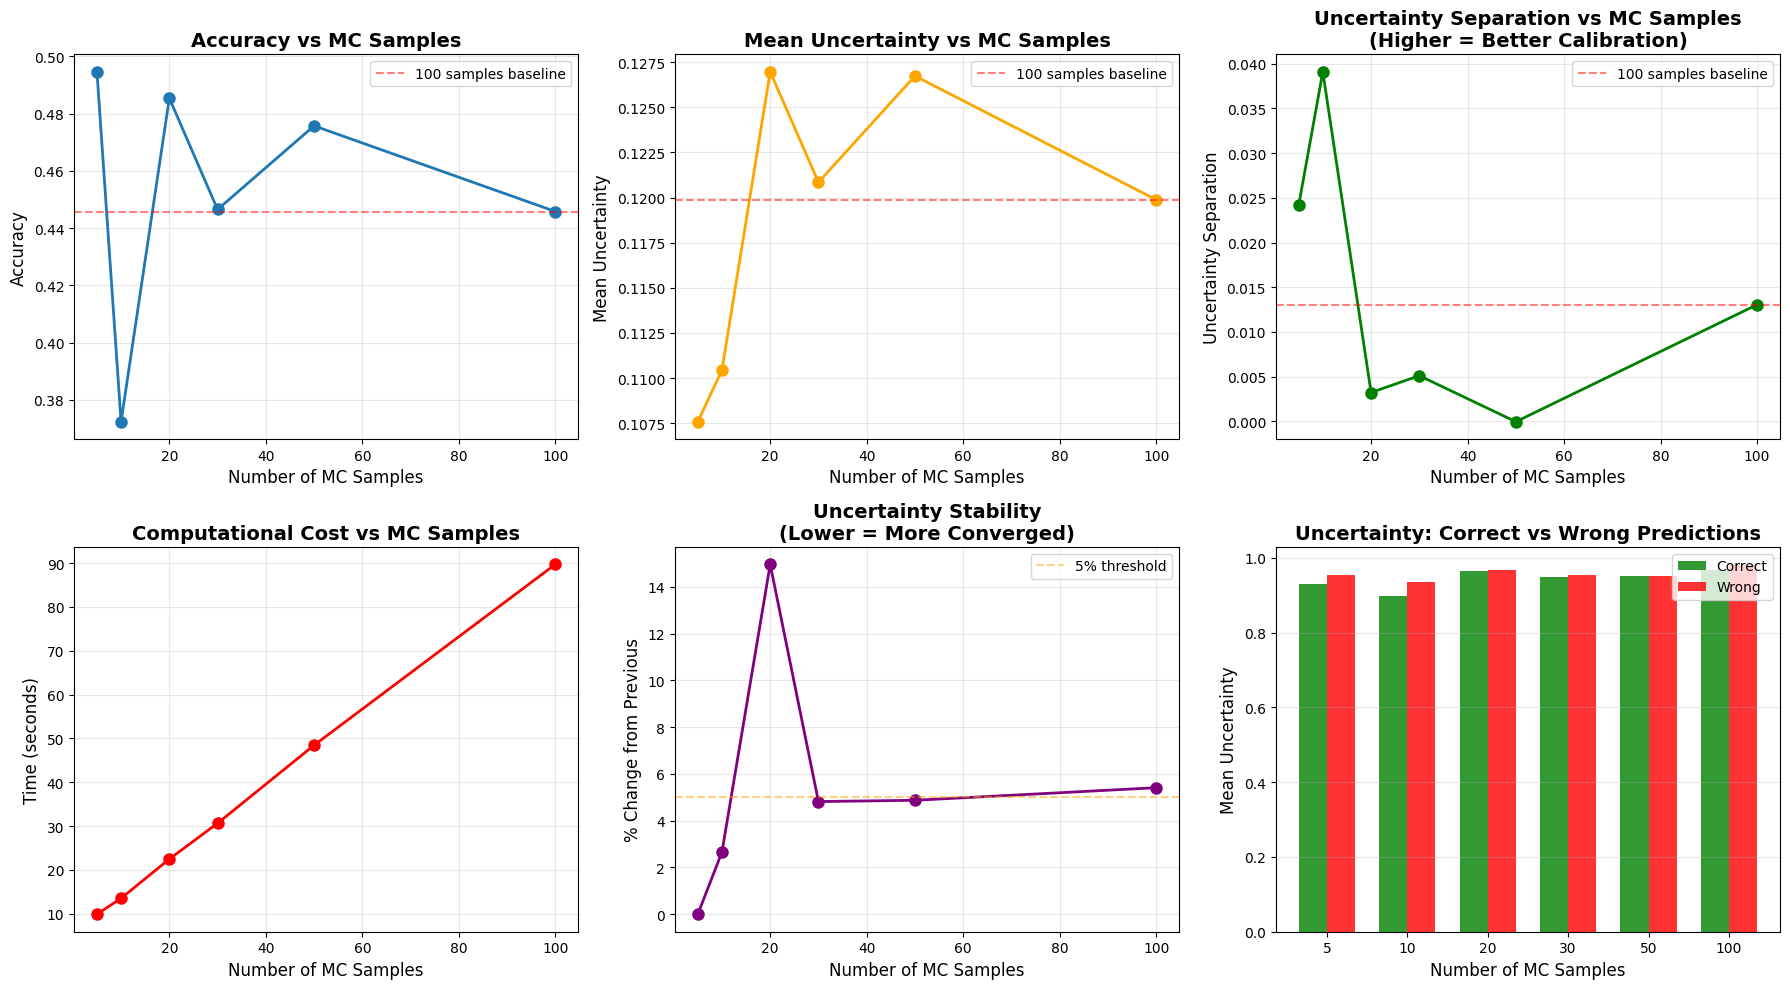


Visualization saved as 'mc_dropout_convergence_study.png'


In [11]:
# ==========================================
# VISUALIZE CONVERGENCE
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Accuracy vs Samples
axes[0, 0].plot(df_convergence['n_samples'], df_convergence['accuracy'], 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of MC Samples', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy vs MC Samples', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=df_convergence['accuracy'].iloc[-1], color='r', linestyle='--', alpha=0.5, label='100 samples baseline')
axes[0, 0].legend()

# 2. Mean Uncertainty vs Samples
axes[0, 1].plot(df_convergence['n_samples'], df_convergence['mean_uncertainty'], 'o-', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Number of MC Samples', fontsize=12)
axes[0, 1].set_ylabel('Mean Uncertainty', fontsize=12)
axes[0, 1].set_title('Mean Uncertainty vs MC Samples', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=df_convergence['mean_uncertainty'].iloc[-1], color='r', linestyle='--', alpha=0.5, label='100 samples baseline')
axes[0, 1].legend()

# 3. Uncertainty Separation vs Samples
axes[0, 2].plot(df_convergence['n_samples'], df_convergence['uncertainty_separation'], 'o-', linewidth=2, markersize=8, color='green')
axes[0, 2].set_xlabel('Number of MC Samples', fontsize=12)
axes[0, 2].set_ylabel('Uncertainty Separation', fontsize=12)
axes[0, 2].set_title('Uncertainty Separation vs MC Samples\n(Higher = Better Calibration)', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=df_convergence['uncertainty_separation'].iloc[-1], color='r', linestyle='--', alpha=0.5, label='100 samples baseline')
axes[0, 2].legend()

# 4. Computational Time vs Samples
axes[1, 0].plot(df_convergence['n_samples'], df_convergence['time_seconds'], 'o-', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Number of MC Samples', fontsize=12)
axes[1, 0].set_ylabel('Time (seconds)', fontsize=12)
axes[1, 0].set_title('Computational Cost vs MC Samples', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Relative Change in Uncertainty (compared to previous)
relative_changes = [0]  # First one has no previous
for i in range(1, len(df_convergence)):
    prev_unc = df_convergence['mean_uncertainty'].iloc[i-1]
    curr_unc = df_convergence['mean_uncertainty'].iloc[i]
    relative_change = abs(curr_unc - prev_unc) / prev_unc * 100
    relative_changes.append(relative_change)

axes[1, 1].plot(df_convergence['n_samples'], relative_changes, 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Number of MC Samples', fontsize=12)
axes[1, 1].set_ylabel('% Change from Previous', fontsize=12)
axes[1, 1].set_title('Uncertainty Stability\n(Lower = More Converged)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='5% threshold')
axes[1, 1].legend()

# 6. Uncertainty: Correct vs Wrong
x_pos = np.arange(len(df_convergence))
width = 0.35

axes[1, 2].bar(x_pos - width/2, df_convergence['uncertainty_when_correct'], width, label='Correct', alpha=0.8, color='green')
axes[1, 2].bar(x_pos + width/2, df_convergence['uncertainty_when_wrong'], width, label='Wrong', alpha=0.8, color='red')
axes[1, 2].set_xlabel('Number of MC Samples', fontsize=12)
axes[1, 2].set_ylabel('Mean Uncertainty', fontsize=12)
axes[1, 2].set_title('Uncertainty: Correct vs Wrong Predictions', fontsize=14, fontweight='bold')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(df_convergence['n_samples'])
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mc_dropout_convergence_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'mc_dropout_convergence_study.png'")

In [14]:
# ==========================================
# ANALYSIS SUMMARY
# ==========================================

print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)

# Find when uncertainty stabilizes (< 5% change from previous)
stabilized_at = None
for i in range(1, len(df_convergence)):
    prev_unc = df_convergence['mean_uncertainty'].iloc[i-1]
    curr_unc = df_convergence['mean_uncertainty'].iloc[i]
    change_pct = abs(curr_unc - prev_unc) / prev_unc * 100

    if change_pct < 5:
        stabilized_at = df_convergence['n_samples'].iloc[i]
        break

print(f"\n1. CONVERGENCE POINT:")
if stabilized_at:
    print(f"   Uncertainty stabilized at n={stabilized_at} samples (<5% change)")
else:
    print(f"   Uncertainty still changing by >5% at n=100")

print(f"\n2. ACCURACY STABILITY:")
acc_range = df_convergence['accuracy'].max() - df_convergence['accuracy'].min()
print(f"   Accuracy range: {acc_range:.4f} ({acc_range*100:.2f}%)")
print(f"   Accuracy at n=30: {df_convergence[df_convergence['n_samples']==30]['accuracy'].values[0]:.4f}")
print(f"   Accuracy at n=100: {df_convergence[df_convergence['n_samples']==100]['accuracy'].values[0]:.4f}")

print(f"\n3. COMPUTATIONAL COST:")
time_30 = df_convergence[df_convergence['n_samples']==30]['time_seconds'].values[0]
time_100 = df_convergence[df_convergence['n_samples']==100]['time_seconds'].values[0]
time_500_est = time_100 * (500/100)  # Estimate for 500

print(f"   Time for n=30:  {time_30:.1f}s")
print(f"   Time for n=100: {time_100:.1f}s")
print(f"   Estimated time for n=500: {time_500_est:.1f}s ({time_500_est/60:.1f} minutes)")
print(f"   Cost multiplier (500 vs 30): {500/30:.1f}x")

print(f"\n4. UNCERTAINTY CALIBRATION:")
sep_30 = df_convergence[df_convergence['n_samples']==30]['uncertainty_separation'].values[0]
sep_100 = df_convergence[df_convergence['n_samples']==100]['uncertainty_separation'].values[0]
sep_improvement = abs(sep_100 - sep_30) / sep_30 * 100

print(f"   Separation at n=30:  {sep_30:.6f}")
print(f"   Separation at n=100: {sep_100:.6f}")
print(f"   Improvement: {sep_improvement:.2f}%")




CONVERGENCE ANALYSIS SUMMARY

1. CONVERGENCE POINT:
   Uncertainty stabilized at n=10 samples (<5% change)

2. ACCURACY STABILITY:
   Accuracy range: 0.1222 (12.22%)
   Accuracy at n=30: 0.4465
   Accuracy at n=100: 0.4458

3. COMPUTATIONAL COST:
   Time for n=30:  30.7s
   Time for n=100: 89.7s
   Estimated time for n=500: 448.6s (7.5 minutes)
   Cost multiplier (500 vs 30): 16.7x

4. UNCERTAINTY CALIBRATION:
   Separation at n=30:  0.005111
   Separation at n=100: 0.013054
   Improvement: 155.39%
